In [60]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder , StandardScaler 
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix , ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression




In [61]:
data= pd.read_csv('Cleaned_data.csv')
df =data.copy()


In [62]:
df['country'].unique()

array(['PRT', 'GBR', 'ESP', 'IRL', 'FRA', 'Other', 'DEU', 'BEL', 'ITA',
       'NLD', 'BRA'], dtype=object)

In [63]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_month,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,total_of_special_requests,total_stay,total_guests,had_previous_cancellation,room_class_changed
0,Resort Hotel,0,342,July,1,0,0,2,0.0,0,...,3,No Deposit,0,Transient,0.0,0,0,2.0,0,1
1,Resort Hotel,0,7,July,1,0,1,1,0.0,0,...,0,No Deposit,0,Transient,75.0,0,1,1.0,0,0
2,Resort Hotel,0,13,July,1,0,1,1,0.0,0,...,0,No Deposit,0,Transient,75.0,0,1,1.0,0,1
3,Resort Hotel,0,14,July,1,0,2,2,0.0,0,...,0,No Deposit,0,Transient,98.0,1,2,2.0,0,1
4,Resort Hotel,0,14,July,1,0,2,2,0.0,0,...,0,No Deposit,0,Transient,98.0,1,2,2.0,0,1


In [64]:
df.shape

(109372, 25)

In [65]:
X = df.drop('is_canceled' , axis =1)
y = df['is_canceled']

In [66]:
X_train , X_test , y_train , y_test = train_test_split(X , y ,  test_size= 0.2 ,  shuffle=True ,random_state=42)

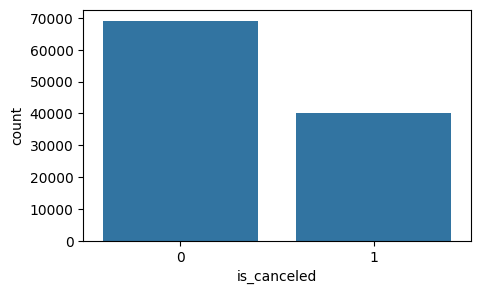

In [67]:
plt.figure(figsize=(5,3))
sns.countplot(x =df['is_canceled'])
plt.show()

In [68]:
ratio = (df['is_canceled'] == 0).sum() / (df['is_canceled'] == 1).sum()

In [69]:
numeric_col= X.select_dtypes(include='number').columns

In [70]:
cat_col= X.select_dtypes(exclude='number').columns

In [71]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_col),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_col)
])

#     1- RandomForest

Select best parameter

In [72]:
rf_pipeline = Pipeline([ ('preprocessor', preprocessor), ('model', RandomForestClassifier(class_weight='balanced',random_state= 42)) ])

In [73]:
param_grid = {
    'model__n_estimators': [50,100, 200],
    'model__max_depth': [5, 10,15]
}

In [74]:
grid = GridSearchCV(estimator=rf_pipeline, param_grid=param_grid  ,cv=5 ,n_jobs =-1,scoring = 'accuracy' )

In [75]:
grid.fit(X_train ,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [5, 10, ...], 'model__n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is 

In [76]:
print(grid.best_params_)

{'model__max_depth': 15, 'model__n_estimators': 200}


In [77]:
best_model_rf = grid.best_estimator_
y_pred_rf = best_model_rf.predict(X_test)
#y_pred = (best_model.predict_proba(X_test)[:,1] > 0.45)

In [78]:
print(grid.best_score_)

0.8523606632215719


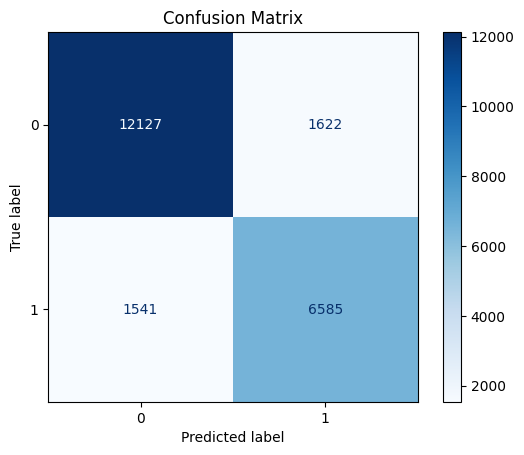

In [79]:
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

In [80]:
auc = roc_auc_score(y_test, y_pred_rf)
print(f'Roc_auc_score : {auc}')
print(classification_report(y_test, y_pred_rf))

Roc_auc_score : 0.8461947927316201
              precision    recall  f1-score   support

           0       0.89      0.88      0.88     13749
           1       0.80      0.81      0.81      8126

    accuracy                           0.86     21875
   macro avg       0.84      0.85      0.85     21875
weighted avg       0.86      0.86      0.86     21875



#     2- XGBoost

In [81]:
xgb_pipeline = Pipeline([ ('preprocessor', preprocessor), ('model', XGBClassifier(scale_pos_weight  =ratio, eval_metric='logloss')) ])

param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5, 10],
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__subsample': [0.8, 1]
}


grid = GridSearchCV(estimator=xgb_pipeline , param_grid=param_grid ,cv =5 , scoring='accuracy' , n_jobs=-1)

In [82]:
grid.fit(X_train , y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.01, 0.1, ...], 'model__max_depth': [3, 5, ...], 'model__n_estimators': [100, 200], 'model__subsample': [0.8, 1]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time fo

In [83]:
print(grid.best_params_)

{'model__learning_rate': 0.2, 'model__max_depth': 10, 'model__n_estimators': 200, 'model__subsample': 0.8}


In [84]:
print(grid.best_score_)

0.8708069561525965


In [85]:
best_model_xgb = grid.best_estimator_
y_pred_xgb = best_model_xgb.predict(X_test)
#y_pred = (best_model.predict_proba(X_test)[:,1] > 0.4)

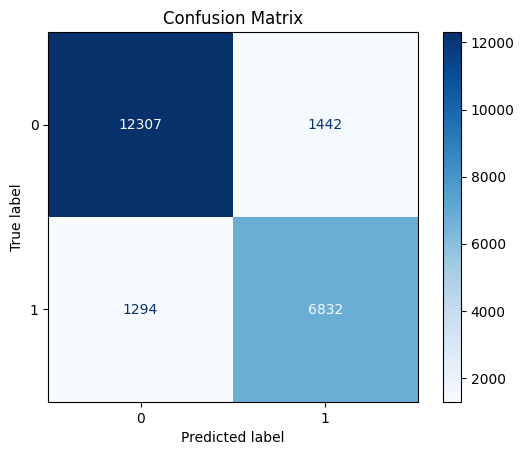

In [86]:
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

In [87]:
auc = roc_auc_score(y_test, y_pred_xgb)
print(f'Roc_auc_score : {auc}')
print(classification_report(y_test, y_pred_xgb))

Roc_auc_score : 0.867938852805745
              precision    recall  f1-score   support

           0       0.90      0.90      0.90     13749
           1       0.83      0.84      0.83      8126

    accuracy                           0.87     21875
   macro avg       0.87      0.87      0.87     21875
weighted avg       0.88      0.87      0.88     21875



#     3- logisric Regression

In [88]:
logreg_pipeline = Pipeline([
     ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000,class_weight='balanced'))
])
param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l2'],
    'model__solver': ['lbfgs', 'liblinear']
}
grid = GridSearchCV(
    logreg_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train, y_train)

c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__penalty': ['l2'], 'model__solver': ['lbfgs', 'liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is display

In [89]:
print(grid.best_params_)
print(grid.best_score_)

y_pred_logreg = grid.predict(X_test)

{'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
0.8825196217808797


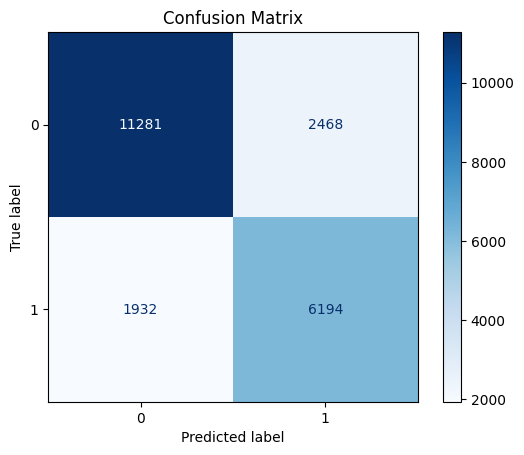

In [90]:
cm = confusion_matrix(y_test, y_pred_logreg)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

In [91]:
auc = roc_auc_score(y_test, y_pred_logreg)
print(f'Roc_auc_score : {auc}')
print(classification_report(y_test, y_pred_logreg))

Roc_auc_score : 0.7913703414440254
              precision    recall  f1-score   support

           0       0.85      0.82      0.84     13749
           1       0.72      0.76      0.74      8126

    accuracy                           0.80     21875
   macro avg       0.78      0.79      0.79     21875
weighted avg       0.80      0.80      0.80     21875



Save_model

In [92]:
import pickle

bundle = {
    'model': best_model_xgb,
    'features': X.columns.tolist()
}

with open('hotel_model.pkl', 'wb') as f:
    pickle.dump(bundle, f)